## **SIFT Feature Extraction for Flower Image Classification**

### **Libraries**

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import cv2 as cv
import glob
import cv2
import os

### **Data loading**

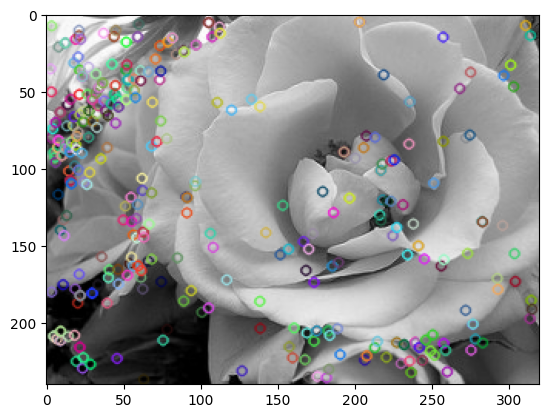

In [2]:
image = cv2.imread('/kaggle/input/flowers/flowers/rose/12240303_80d87f77a3_n.jpg')
crop_image = image[200:, 200:]
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
sift = cv.SIFT_create()
kp, des = sift.detectAndCompute(gray, None)
image = cv.drawKeypoints(gray, kp, image)
cv.imwrite('sift_keypoints.jpg', image)
plt.imshow(image)
plt.show()

In [3]:
image_paths = []
labels = []

dataset_path = "/kaggle/input/flowers/flowers"

classes = os.listdir(dataset_path)
print("Classes found:", classes)

Classes found: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


In [4]:
for class_name in classes:
    class_dir = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    for img_path in glob.glob(os.path.join(class_dir, "*.jpg")):
        image_paths.append(img_path)
        labels.append(class_name)

print(f"Total images loaded: {len(image_paths)}")

Total images loaded: 4317


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels, 
    test_size=0.2, 
    stratify=labels,
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 3453
Testing samples: 864


In [6]:
print("Train class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))

Train class distribution: Counter({'dandelion': 842, 'tulip': 787, 'rose': 627, 'daisy': 611, 'sunflower': 586})
Test class distribution: Counter({'dandelion': 210, 'tulip': 197, 'rose': 157, 'daisy': 153, 'sunflower': 147})


### **KNN Classifier**

In [7]:
# function to extract the mean SIFT descriptor for one image
def extract_sift_feature(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(gray, None)
    if des is None:
        return None
    return np.mean(des, axis=0)

In [8]:
# extract features for training set
X_train_features, y_train_filtered = [], []
for img_path, label in tqdm(zip(X_train, y_train), total=len(X_train), desc="Extracting train features"):
    feat = extract_sift_feature(img_path)
    if feat is not None:
        X_train_features.append(feat)
        y_train_filtered.append(label)

Extracting train features: 100%|██████████| 3453/3453 [02:48<00:00, 20.47it/s]


In [14]:
# extract features for testing set
X_test_features, y_test_filtered = [], []
for img_path, label in tqdm(zip(X_test, y_test), total=len(X_test), desc="Extracting test features"):
    feat = extract_sift_feature(img_path)
    if feat is not None:
        X_test_features.append(feat)
        y_test_filtered.append(label)

Extracting test features: 100%|██████████| 864/864 [00:37<00:00, 23.01it/s]


In [16]:
X_train_features = np.array(X_train_features)
X_test_features = np.array(X_test_features)

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

In [18]:
knn.fit(X_train_features, y_train_filtered)

KNeighborsClassifier()

In [19]:
# evaluation
accuracy = knn.score(X_test_features, y_test_filtered)
print(f"accuracy: {accuracy * 100:.2f}%")

accuracy: 44.91%


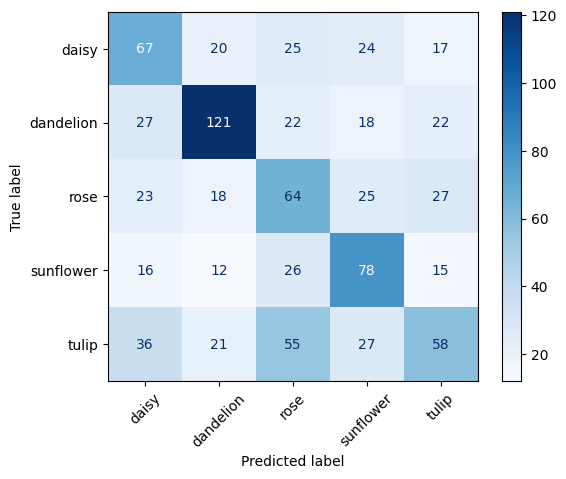

In [20]:
cm = confusion_matrix(y_test_filtered, knn.predict(X_test_features))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_train_filtered))
disp.plot(cmap='Blues', xticks_rotation=45)

In [21]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import cv2
from tqdm import tqdm

# 1. Collect all descriptors from training images
all_descriptors = []
for img_path in tqdm(X_train, desc="Collecting descriptors"):
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = cv2.SIFT_create().detectAndCompute(gray, None)
    if des is not None:
        all_descriptors.append(des)

all_descriptors = np.vstack(all_descriptors)

# 2. KMeans clustering to build the vocabulary
num_clusters = 100  # tune this (50, 100, 200, etc.)
kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(all_descriptors)

# 3. Function to compute histogram features
def get_bovw_feature(image_path, kmeans):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = cv2.SIFT_create().detectAndCompute(gray, None)
    if des is None:
        return np.zeros(num_clusters)
    clusters = kmeans.predict(des)
    hist, _ = np.histogram(clusters, bins=np.arange(num_clusters+1))
    return hist.astype(float) / np.sum(hist)

# 4. Extract BoVW histograms for train and test sets
X_train_bovw = []
for path in tqdm(X_train, desc="Building train histograms"):
    feat = get_bovw_feature(path, kmeans)
    X_train_bovw.append(feat)
    
X_test_bovw = []
for path in tqdm(X_test, desc="Building test histograms"):
    feat = get_bovw_feature(path, kmeans)
    X_test_bovw.append(feat)

X_train_bovw = np.array(X_train_bovw)
X_test_bovw = np.array(X_test_bovw)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
Building test histograms: 100%|██████████| 864/864 [00:30<00:00, 28.44it/s]


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_bovw, y_train)
y_pred = knn.predict(X_test_bovw)
acc = accuracy_score(y_test, y_pred)

print(f"Improved accuracy with BoVW: {acc*100:.2f}%")

Improved accuracy with BoVW: 45.49%


In [5]:
import cv2
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [3]:
# === STEP 1: Define dataset path ===
dataset_path = '/kaggle/input/flowers/flowers'

# === STEP 2: Initialize lists ===
descriptors_list = []
labels_list = []

In [ ]:
# === STEP 3: Loop through all folders and images ===
sift = cv2.SIFT_create()

# for img_path, label in tqdm(zip(X_test, y_test), total=len(X_test), desc="Extracting test features"):
for class_label in tqdm( os.listdir(dataset_path), total=len(os.listdir(dataset_path))):

    class_dir = os.path.join(dataset_path, class_label)
    if not os.path.isdir(class_dir):
        continue
    
    for file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Extract SIFT descriptors
        keypoints, descriptors = sift.detectAndCompute(gray, None)
        if descriptors is not None:
            for d in descriptors:
                descriptors_list.append(d)
                labels_list.append(class_label)

 40%|████      | 2/5 [01:04<01:33, 31.24s/it]

In [ ]:
# === STEP 4: Convert lists to numpy arrays ===
X = np.array(descriptors_list)
y = np.array(labels_list)

In [ ]:
# === STEP 5: Split into training and testing sets ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:






# === STEP 6: Train KNN classifier ===
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# === STEP 7: Evaluate ===
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Classifier Accuracy: {accuracy * 100:.2f}%")

NameError: name 'tqdm' is not defined